In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
from tqdm import tqdm
import matplotlib
import pickle as pi
# from funcs_for_kappa_BHZ import localgap_sys
from funcs_for_kappa_3D import localgap_sys_3D
from load_files_from_cluster import load_cluster_results

import matplotlib.pyplot as plt
import cmasher as csh
import matplotlib.gridspec as gridspec

matplotlib.rcParams.update(
    {
        "font.size": 10,
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern"],
    }
)
aps_figwidth = 6.6
aps_halfwidth = 3.375

In [3]:
# model parameters
system_size = 10
A = 1.0
B = 1.0
onsite_disorder = 0
bond_power = 1.1
Delta = 2
# localizer parameters
E0 = 0.0
kappa = 1



# kappa vs E

In [13]:
kappa_values = np.linspace(0, 25, 50)
E_values = np.linspace(-2.5, 2.5, 50)

Delta_values = np.linspace(-2, 4, 50)
W_values = np.linspace(0, 15, 50)
# localgap_grid = np.zeros((len(kappa_values), len(E_values)))

# for i, kappa in tqdm(enumerate(kappa_values)):
#     for j, E0 in enumerate(E_values):
#         localgap_grid[i, j] = localgap_sys(
#             system_size=system_size,
#             Delta=Delta,
#             A=A,
#             B=B,
#             bond_power=bond_power,
#             onsite_disorder=onsite_disorder,
#             E0=E0,
#             kappa=kappa
#         )
    
        
        

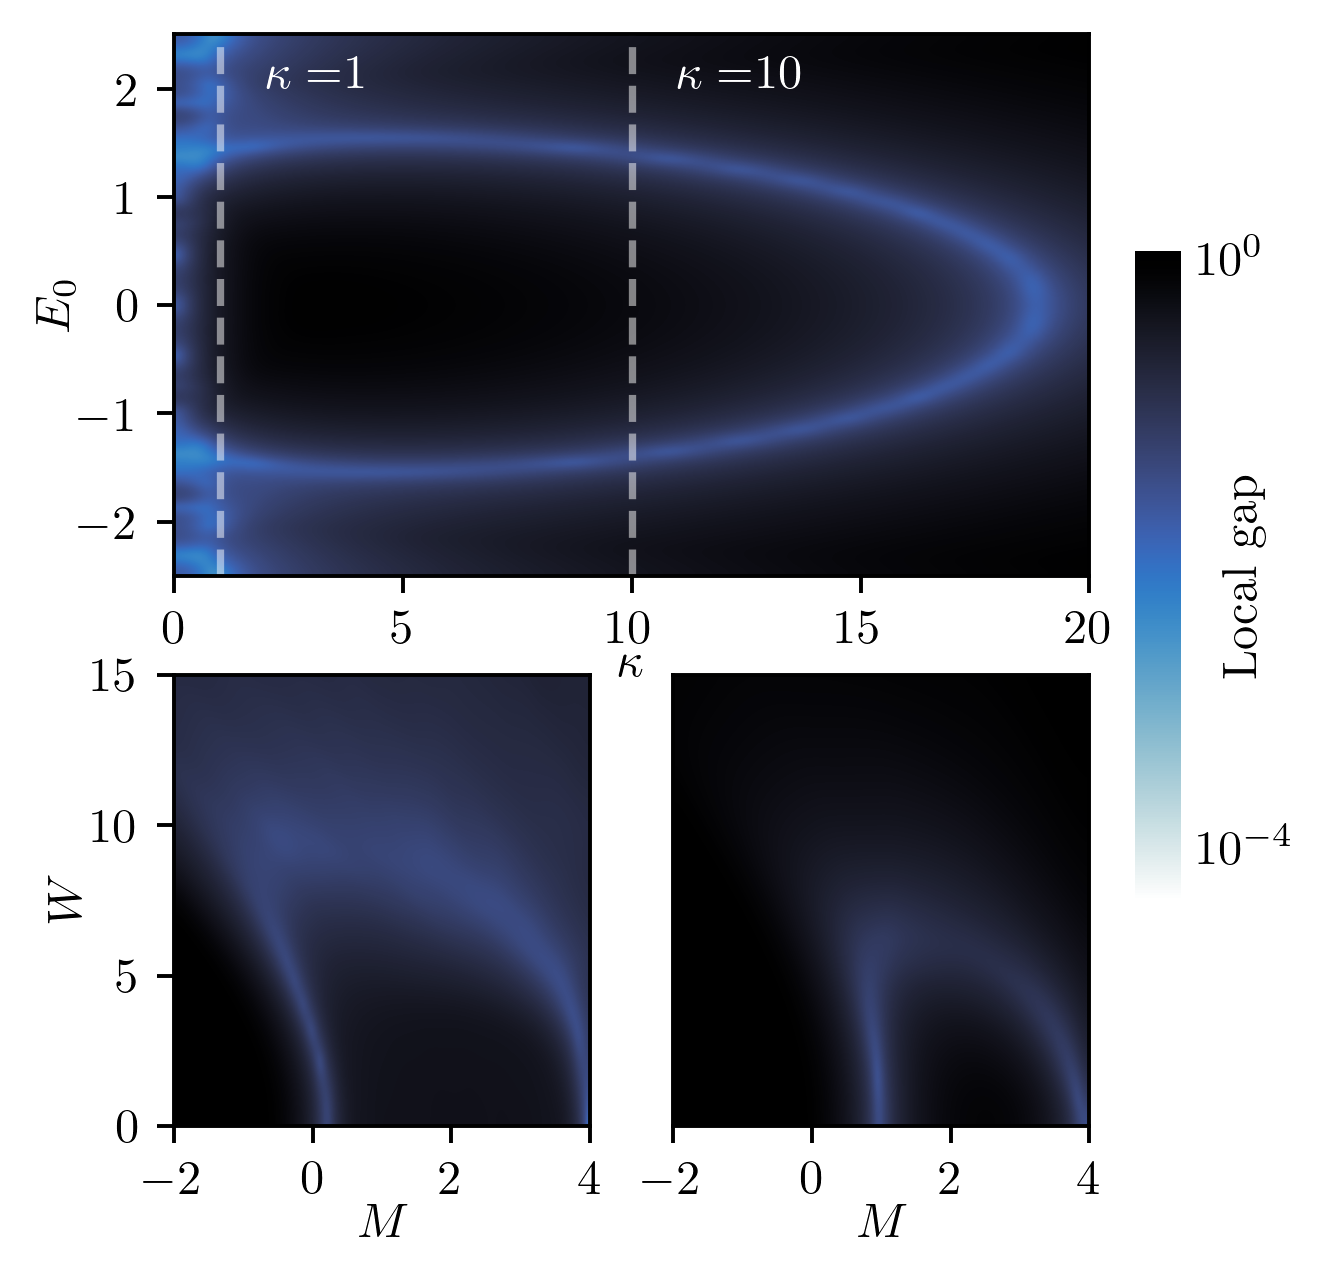

In [14]:
localgap_grid = pi.load(open("data/2D_localgap_kappa_E_grid.pkl", "rb"))
avg_locgap = [
    pi.load(open("data/2D_kappa-1_locgap_Delta_W_grid.pkl", "rb")),
    pi.load(open("data/2D_kappa-10_locgap_Delta_W_grid.pkl", "rb"))
]

fig = plt.figure(figsize=(aps_halfwidth, aps_halfwidth*1.2), dpi=350)
gs = gridspec.GridSpec(
    2, 2,
    height_ratios=[1.2, 1],
    width_ratios=[1, 1], 
    )

ax_top = fig.add_subplot(gs[0, :2])
ax_bl = fig.add_subplot(gs[1, 0])
ax_br = fig.add_subplot(gs[1, 1])


im = ax_top.imshow(
    localgap_grid.T,
    extent=(kappa_values[0], kappa_values[-1], E_values[0], E_values[-1]),
    origin="lower",
    aspect="auto",
    cmap=csh.arctic_r,
    interpolation='bicubic',
    norm='log',
    rasterized=True,
)


for x in [1,10]:
    ax_top.axvline(x=x, color='white', linestyle='--', alpha=0.5)
    ax_top.text(x+1, E_values[-1]-0.5, r'$\kappa=$'+str(x), color='white')

ax_top.set_xlim(0,20)

ax_top.set_xlabel(r'$\kappa$', labelpad=-2)
ax_top.set_ylabel(r'$E_0$', labelpad=0)
# plt.savefig("localgap_kappa_grid.png", bbox_inches='tight')



for i, axes in enumerate([ax_bl, ax_br]):
    axes.imshow(
        avg_locgap[i].T,
        extent=(Delta_values[0], Delta_values[-1], W_values[0], W_values[-1]),
        origin="lower",
        aspect="auto",
        cmap=csh.arctic_r,
        interpolation='bicubic',
        norm='log',
        vmin=10**np.round(np.min(np.log10(localgap_grid[:,:].T))),
        vmax=10**np.floor(np.max(np.log10(localgap_grid[:,:].T))),
        rasterized=True,
    )
    axes.set_xticks([-2, 0, 2, 4])
    axes.set_xlabel(r'$M$', labelpad=0)
    
ax_bl.set_ylabel(r'$W$', labelpad=0)
ax_br.set_yticks([])


ax_cbar = ax_top.inset_axes([1.05, -0.6, 0.05, 1.2])
cbar = fig.colorbar(
    im,
    cax=ax_cbar,
    orientation='vertical',
    fraction=1,
    norm='log',
    # label='Local gap',
    )
cbar.set_label('Local gap', labelpad=-15)
cbar.outline.set_visible(False)
cbar.ax.minorticks_off()     
cbar.ax.tick_params(length=0)      
cbar.set_ticks([10**np.round(np.min(np.log10(localgap_grid[:,:].T))), 10**np.floor(np.max(np.log10(localgap_grid[:,:].T)))])


ax_cbar.tick_params(length=0)
ax_cbar.set_frame_on(False)
ax_cbar.set_rasterized(True)
# cbar.outline.set_visible(False)

label = ['a)', 'b)', 'c)']
# for axes in [ax_top, ax_bl, ax_br]:
#     axes.text(label.pop(0), transform=axes.transAxes, xy=(0.05, 0.9), color='white', y=0.9, s=axes.texts[0].get_text(), fontsize=12)

In [ ]:
fig.savefig("localgap_kappa_grid.pdf", bbox_inches='tight', dpi=350)


# 3D

In [43]:
output_a = load_cluster_results(
    "results_3d_a",
    "results_kappa*_E0_50_L10.h5",
)
output_bc = load_cluster_results(
    "results_3d_bc",
    "results_seed2.0_kappa_2_L10.h5",
    check_reals=50,
)

Loaded 50 files from results_3d_a
kappa range: [0.000,25.000]
Parameters for the calculation:
  A: 1
  Emax: 2.5
  Emin: -2.5
  MJ: 1.5
  beta: 1
  bond_lengthscale: 0.1
  bond_power: 0.1
  kappa: 0.0
  kappa_shift: 0
  num_reals: 50
  onsite_disorder: 0
  par_variable_name: kappa
  resolution: 10
  seed: 0
  system_size: 10
Outputs obtained from the calculation: ['local_gap']
Loaded 1 files from results_3d_bc
seed range: [2.000,2.000]
Parameters for the calculation:
  A: 1
  Mmax: 4.0
  Mmin: 0.0
  Wmax: 10.0
  Wmin: 0.0
  beta: 1
  bond_lengthscale: 0.1
  bond_power: 0.1
  kappa: 2
  kappa_shift: 0
  par_variable_name: seed
  resolution: 10
  seed: 2
  system_size: 10
Outputs obtained from the calculation: ['local_gap_grid']


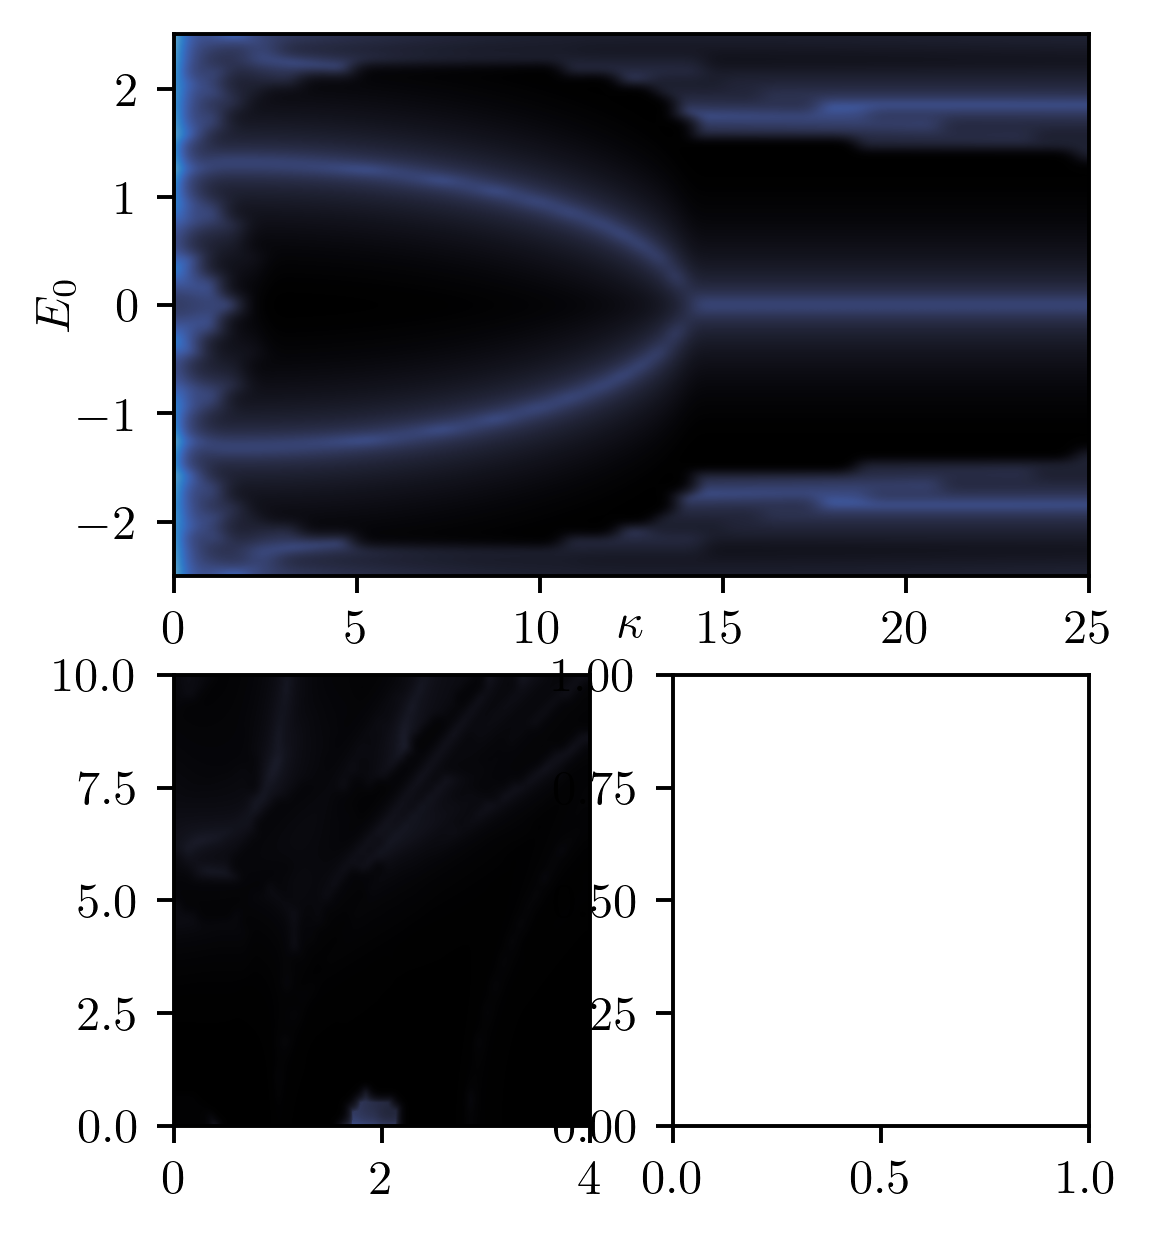

In [48]:
M_values = np.linspace(0, 4, 50)
kappa_values = np.linspace(0, 25, 50)
E_values = np.linspace(-2.5, 2.5, 50)

localgap_grid = np.array(output_a['local_gap'])


fig = plt.figure(figsize=(aps_halfwidth, aps_halfwidth*1.2), dpi=350)
gs = gridspec.GridSpec(
    2, 2,
    height_ratios=[1.2, 1],
    width_ratios=[1, 1], 
    )

ax_top = fig.add_subplot(gs[0, :2])
ax_bl = fig.add_subplot(gs[1, 0])
ax_br = fig.add_subplot(gs[1, 1])


im = ax_top.imshow(
    localgap_grid.T,
    extent=(kappa_values[0], kappa_values[-1], E_values[0], E_values[-1]),
    origin="lower",
    aspect="auto",
    cmap=csh.arctic_r,
    interpolation='bicubic',
    norm='log',
    rasterized=True,
)


# colorbar

# for x in [1,10]:
#     ax_top.axvline(x=x, color='white', linestyle='--', alpha=0.5)
#     ax_top.text(x+1, E_values[-1]-0.5, r'$\kappa=$'+str(x), color='white')

# ax_top.set_xlim(0,20)

ax_top.set_xlabel(r'$\kappa$', labelpad=-10)
ax_top.set_ylabel(r'$E_0$', labelpad=0)
# # plt.savefig("localgap_kappa_grid.png", bbox_inches='tight')

localgap_b = np.array(output_bc['local_gap_grid'])
M_values = np.linspace(0, 4, 50)
W_values = np.linspace(0, 10, 50)
axes = ax_bl
# for i, axes in enumerate([ax_bl, ax_br]):
im = axes.imshow(
    localgap_b.T,
    extent=(M_values[0], M_values[-1], W_values[0], W_values[-1]),
    origin="lower",
    aspect="auto",
    cmap=csh.arctic_r,
    interpolation='bicubic',
    norm='log',
    rasterized=True,
)
# axes.set_xticks([-2, 0, 2, 4])
# axes.set_xlabel(r'$M$', labelpad=0)
# fig.colorbar(
#     im,
#     ax=ax_top,
#     orientation='vertical',
#     fraction=0.05,
#     norm='log',
#     label='Local gap',
#     ticks=[10**np.round(np.min(np.log10(grid[:,:].T))), 10**np.floor(np.max(np.log10(grid[:,:].T)))], )

# ax_bl.set_ylabel(r'$W$', labelpad=0)
# ax_br.set_yticks([])


# ax_cbar = ax_top.inset_axes([1.05, -0.6, 0.05, 1.2])
# cbar = fig.colorbar(
#     im,
#     cax=ax_cbar,
#     orientation='vertical',
#     fraction=1,
#     norm='log',
#     # label='Local gap',
#     )
# cbar.set_label('Local gap', labelpad=-15)
# cbar.outline.set_visible(False)
# cbar.ax.minorticks_off()     
# cbar.ax.tick_params(length=0)      
# cbar.set_ticks([10**np.round(np.min(np.log10(localgap_grid[:,:].T))), 10**np.floor(np.max(np.log10(localgap_grid[:,:].T)))])


# ax_cbar.tick_params(length=0)
# ax_cbar.set_frame_on(False)
# ax_cbar.set_rasterized(True)
# # cbar.outline.set_visible(False)

# label = ['a)', 'b)', 'c)']
# # for axes in [ax_top, ax_bl, ax_br]:
# #     axes.text(label.pop(0), transform=axes.transAxes, xy=(0.05, 0.9), color='white', y=0.9, s=axes.texts[0].get_text(), fontsize=12)

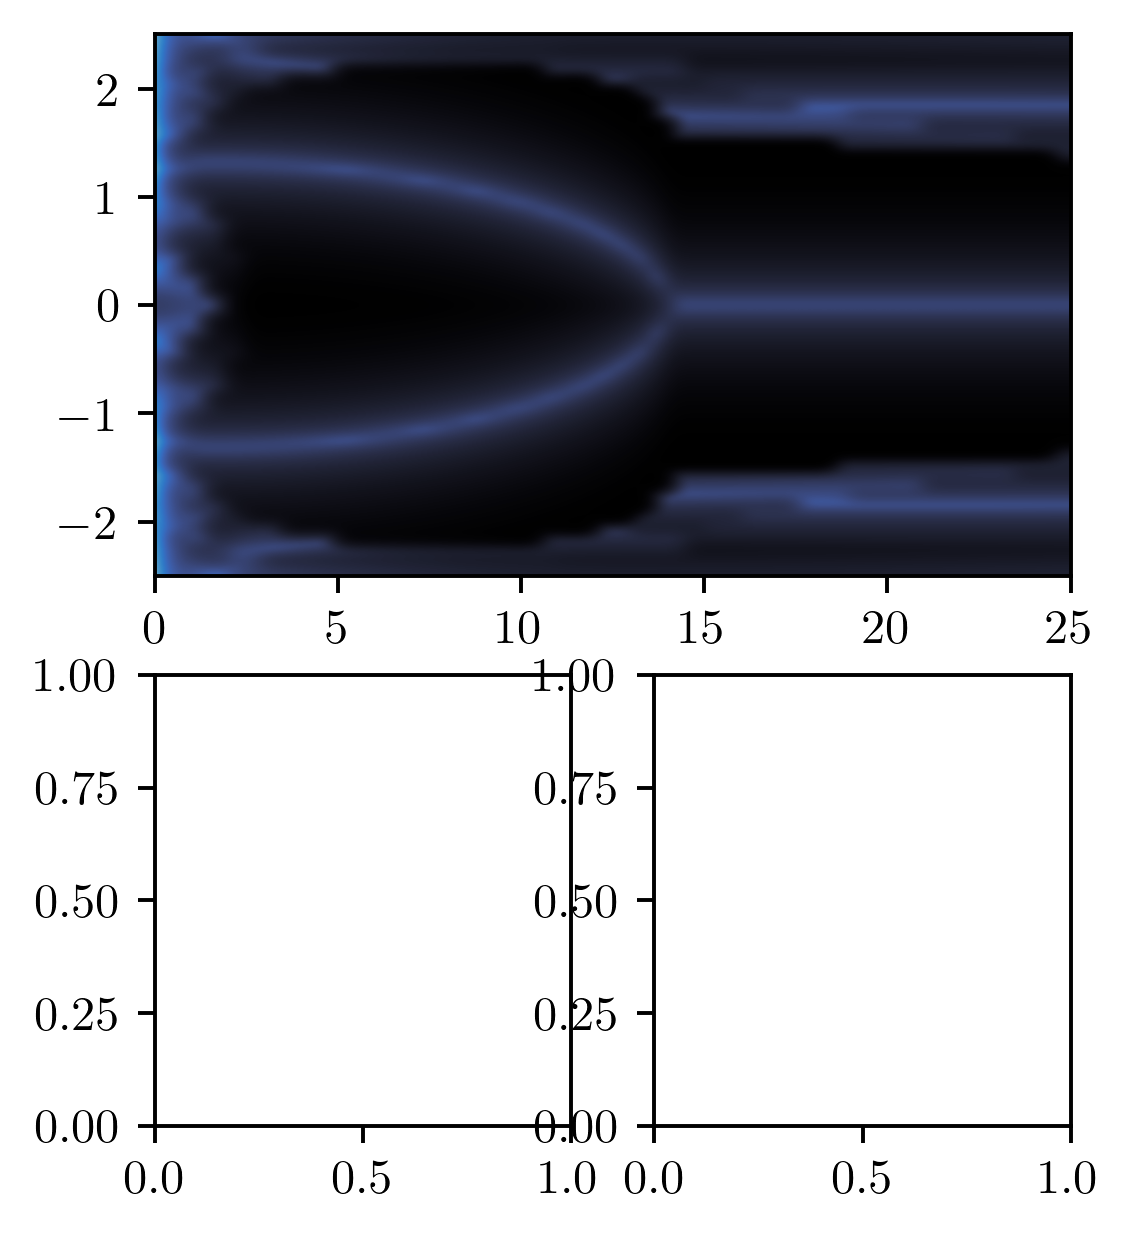